In [1]:
import sys
sys.executable

'/Users/knox.coulter/Documents/GitHub/cmpinf_2211_cloud/venv/bin/python'

In [2]:
import numpy as np
import pandas as pd
import os
import seaborn as sns

In [3]:
dat = pd.read_csv("https://raw.githubusercontent.com/learningtechnologieslab/mds_cloud_computing"
    "/refs/heads/main/apache_spark/loan_data.csv"
)

In [4]:
print(dat.info())
dat.head()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB
None


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [16]:
dat.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

# EDA

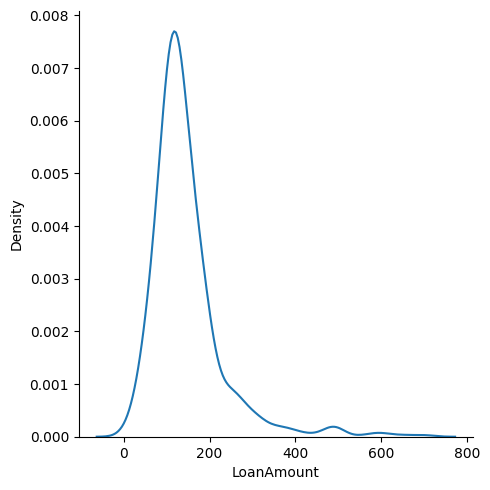

In [7]:
# loan amount distribution
sns.displot(data=dat, x = 'LoanAmount', kind='kde')

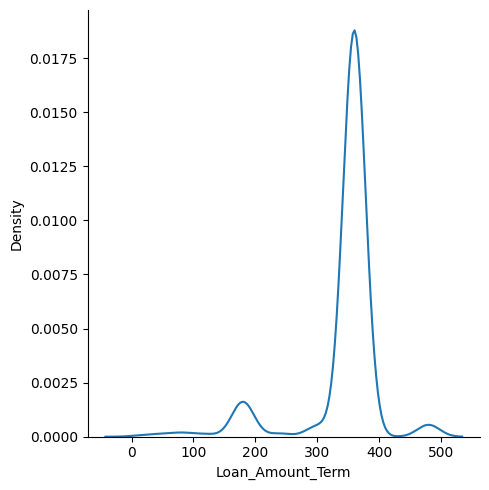

In [9]:
# Loan amount term
sns.displot(data=dat, x = 'Loan_Amount_Term', kind='kde')

In [14]:
# gender mode 
dat.Gender.mode()

0    Male
Name: Gender, dtype: str

In [15]:
# credit history mode
dat.Credit_History.mode()

0    1.0
Name: Credit_History, dtype: float64

In [17]:
dat.ApplicantIncome.describe()

count      614.000000
mean      5403.459283
std       6109.041673
min        150.000000
25%       2877.500000
50%       3812.500000
75%       5795.000000
max      81000.000000
Name: ApplicantIncome, dtype: float64

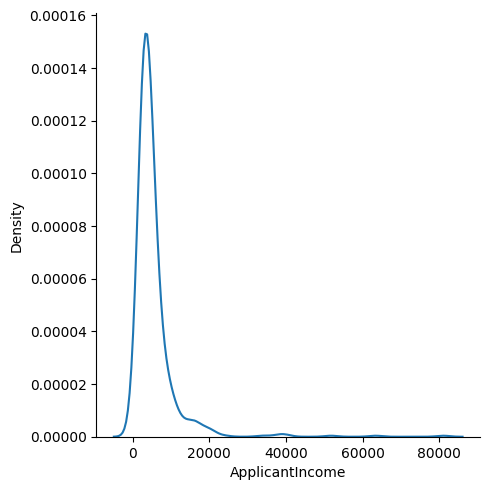

In [18]:
# ApplicantIncome
sns.displot(data=dat, x="ApplicantIncome", kind='kde')

In [24]:
# IQR
iqr = dat.ApplicantIncome.quantile(0.75) - dat.ApplicantIncome.quantile(0.25)

upper_fence = dat.ApplicantIncome.quantile(0.75) + (1.5*iqr)

dat.loc[dat.ApplicantIncome >= upper_fence, :].shape[0]

50

In [26]:
#coapplicantIncome
dat.CoapplicantIncome.describe()

count      614.000000
mean      1621.245798
std       2926.248369
min          0.000000
25%          0.000000
50%       1188.500000
75%       2297.250000
max      41667.000000
Name: CoapplicantIncome, dtype: float64

In [29]:
sum(dat.CoapplicantIncome == 0)

273

In [ ]:
# Non-zero stats
dat.loc[dat.CoapplicantIncome != 0, 'CoapplicantIncome'].describe()

count      341.000000
mean      2919.193314
std       3411.503263
min         16.120001
25%       1644.000000
50%       2166.000000
75%       3230.000000
max      41667.000000
Name: CoapplicantIncome, dtype: float64

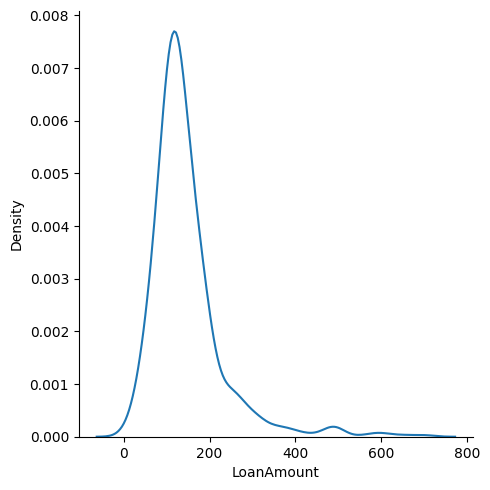

In [32]:
# loan amount
sns.displot(data=dat, x='LoanAmount', kind='kde')

In [33]:
dat.LoanAmount.describe()

count    592.000000
mean     146.412162
std       85.587325
min        9.000000
25%      100.000000
50%      128.000000
75%      168.000000
max      700.000000
Name: LoanAmount, dtype: float64

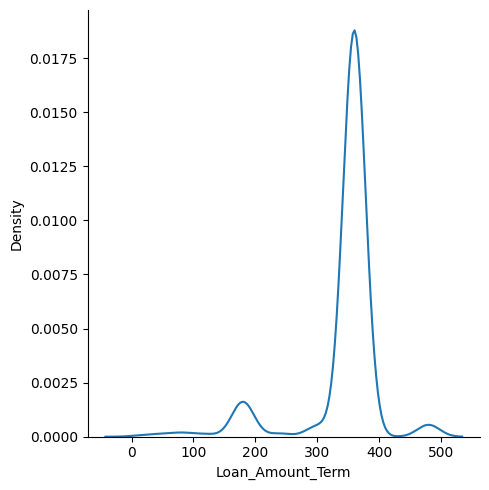

In [37]:
#loanterm
sns.displot(data=dat, x='Loan_Amount_Term', kind='kde')

In [35]:
dat.Loan_Amount_Term.describe()

count    600.00000
mean     342.00000
std       65.12041
min       12.00000
25%      360.00000
50%      360.00000
75%      360.00000
max      480.00000
Name: Loan_Amount_Term, dtype: float64

In [41]:
dat.Loan_Amount_Term.sort_values().unique()

array([ 12.,  36.,  60.,  84., 120., 180., 240., 300., 360., 480.,  nan])